# XGBoost dự báo trực tiếp PM2.5 tại t+24h

## Mục tiêu mô hình và giao thức thực nghiệm

Notebook huấn luyện XGBoost để ước lượng nồng độ PM2.5 đúng 24 giờ sau thời điểm phát hành t. Mô hình kết hợp lịch sử ô nhiễm, thời tiết, chu kỳ thời gian và định danh thành phố, nhờ đó biểu diễn được các tương tác phi tuyến mà mô hình tuyến tính khó mô tả.

Thực nghiệm dùng phép chia thời gian toàn cục **70/15/15 cho Train/Validation/Test**, tương ứng 68.829, 14.679 và 14.679 dòng. Khoảng purge 24 giờ bảo vệ nhãn trực tiếp t+24h khỏi chồng lấn giữa các tập. Siêu tham số và vòng dừng được chọn chỉ bằng Validation RMSE; Test được giữ lại để báo cáo cuối.

**Bảng 1. Các tập Train/Validation/Test theo thời gian; ngày tháng là timestamp của nhãn và số dòng được gộp từ ba thành phố.**


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.casefold() == "model":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "model" / "results"
CANDIDATE_DIR = PROJECT_ROOT / "model" / "candidates"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CANDIDATE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: D:\Project123456\aqi-vietnam\aqi-vietnam4


## 1. Lý do chọn mô hình và hàm mục tiêu

Gradient-boosted trees phù hợp vì dữ liệu có ngưỡng phi tuyến, tương tác giữa biến, biến chu kỳ và biến phân loại thành phố. XGBoost còn hỗ trợ regularization, lấy mẫu hàng/cột và learning curve theo từng boosting round.

Objective là reg:squarederror, tương đương tối thiểu hóa sai số bình phương trong hồi quy. RMSE được theo dõi vì bỏ lỡ đỉnh PM2.5 nghiêm trọng hơn sai lệch nhỏ. Dự đoán được chặn dưới tại 0 vì nồng độ âm không có ý nghĩa vật lý. Mô hình cây không cần chuẩn hóa thang đo; biến phân loại được mã hóa nhất quán bằng bộ xây dựng feature chung.


### Cài đặt có thể tái lập

Cell tiếp theo chứa toàn bộ quy trình fit và lưu artifact. Quan sát Test chỉ được đưa qua mô hình sau khi cấu hình tối ưu theo Validation đã được cố định.


In [2]:
# Full XGBoost training implementation (kept in this notebook).
from typing import Any

import joblib
import numpy as np
import pandas as pd
import xgboost as xgb

from dataclasses import dataclass
import json
from typing import Any, Iterable

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)

HORIZON_HOURS = 24
POLLUTANT_FEATURES = ["pm25", "pm10", "o3", "no2", "so2", "co"]
WEATHER_FEATURES = [
    "temp", "humidity", "wind_speed", "wind_dir", "precip", "pressure", "cloud_cover",
]
TEMPORAL_FEATURES = ["hour", "day_of_week", "month", "is_weekend", "day_of_year"]
HISTORY_FEATURES = [
    "pm25_lag_1h", "pm25_lag_3h", "pm25_lag_6h", "pm25_lag_12h",
    "pm25_lag_24h", "pm25_lag_48h", "pm25_lag_72h", "pm25_lag_96h",
    "pm25_lag_120h", "pm25_lag_144h", "pm25_lag_168h",
    "pm25_roll_6h", "pm25_roll_12h", "pm25_roll_24h", "pm25_roll_72h",
    "pm25_roll_168h", "pm25_std_6h", "pm25_std_12h", "pm25_std_24h",
    "pm25_std_72h", "pm25_std_168h", "pm25_min_24h", "pm25_max_24h",
    "pm25_delta_1h", "pm25_delta_3h", "pm25_delta_24h",
    "pm25_roll_ratio_6h_24h", "pm25_roll_ratio_24h_72h",
    "pm25_same_hour_mean_7d", "pm25_same_hour_median_7d",
    "pm25_same_hour_std_7d", "pm25_same_hour_min_7d",
    "pm25_same_hour_max_7d", "pm25_same_hour_ratio_7d", "pm25_weekly_delta",
]
ENGINEERED_FEATURES = [
    "ventilation_index", "humid_stagnation", "rain_flag", "calm_wind",
    "high_humidity", "wind_x", "wind_y", "hour_sin", "hour_cos",
    "day_sin", "day_cos", "month_sin", "month_cos", "pm25_pm10_ratio",
    "no2_co_ratio",
]
NUMERIC_FEATURES_FULL = (
    POLLUTANT_FEATURES
    + WEATHER_FEATURES
    + TEMPORAL_FEATURES
    + HISTORY_FEATURES
    + ENGINEERED_FEATURES
)
CATEGORICAL_FEATURES = ["city", "season"]
PM25_BINS = [-np.inf, 9.0, 35.4, 55.4, 125.4, 225.4, np.inf]
PM25_LABELS = ["Good", "Moderate", "USG", "Unhealthy", "Very Unhealthy", "Hazardous"]


@dataclass(frozen=True)
class TemporalSplit:
    train_mask: pd.Series
    val_mask: pd.Series
    test_mask: pd.Series
    train_cut: pd.Timestamp
    val_cut: pd.Timestamp
    purge_hours: int

    def summary(self, frame: pd.DataFrame) -> dict[str, Any]:
        output: dict[str, Any] = {
            "strategy": "global chronological 70/15/15 split by target time with purge gaps",
            "train_cut": self.train_cut.isoformat(),
            "val_cut": self.val_cut.isoformat(),
            "purge_hours": self.purge_hours,
        }
        for name, mask in (
            ("train", self.train_mask),
            ("validation", self.val_mask),
            ("test", self.test_mask),
        ):
            part = frame.loc[mask]
            output[name] = {
                "rows": int(len(part)),
                "source_start": part["datetime"].min().isoformat(),
                "source_end": part["datetime"].max().isoformat(),
                "target_start": part["target_time"].min().isoformat(),
                "target_end": part["target_time"].max().isoformat(),
            }
        return output


def make_supervised_frame(df: pd.DataFrame, horizon_hours: int = HORIZON_HOURS) -> pd.DataFrame:
    frame = df.copy()
    frame["datetime"] = pd.to_datetime(frame["datetime"])
    frame = frame.sort_values(["city", "datetime"]).reset_index(drop=True)
    if frame.duplicated(["city", "datetime"]).any():
        raise ValueError("Duplicate city/datetime rows prevent exact t+24 target alignment.")

    frame["target_time"] = frame["datetime"] + pd.Timedelta(hours=horizon_hours)
    targets = frame[["city", "datetime", "pm25"]].rename(
        columns={"datetime": "target_time", "pm25": "target_pm25_24h"}
    )
    return frame.merge(targets, on=["city", "target_time"], how="left", validate="many_to_one")


def temporal_split(
    frame: pd.DataFrame,
    train_fraction: float = 0.70,
    validation_fraction: float = 0.15,
    purge_hours: int = HORIZON_HOURS,
) -> TemporalSplit:
    if train_fraction <= 0 or validation_fraction <= 0 or train_fraction + validation_fraction >= 1:
        raise ValueError("Temporal split must leave non-empty Train, Validation and Test sets.")
    unique_times = pd.Series(pd.to_datetime(frame["target_time"]).dropna().sort_values().unique())
    if len(unique_times) < 100:
        raise ValueError("Not enough target timestamps for a stable temporal split.")

    train_cut = pd.Timestamp(unique_times.iloc[int(len(unique_times) * train_fraction)])
    val_cut = pd.Timestamp(unique_times.iloc[int(len(unique_times) * (train_fraction + validation_fraction))])
    purge = pd.Timedelta(hours=purge_hours)
    target_time = pd.to_datetime(frame["target_time"])
    train_mask = target_time < train_cut
    val_mask = (target_time >= train_cut + purge) & (target_time < val_cut)
    test_mask = target_time >= val_cut + purge
    if not train_mask.any() or not val_mask.any() or not test_mask.any():
        raise ValueError("Temporal split produced an empty partition.")
    return TemporalSplit(train_mask, val_mask, test_mask, train_cut, val_cut, purge_hours)


def pm25_category(values: Any) -> pd.Series:
    array = np.asarray(values, dtype=float)
    return pd.Series(pd.cut(array, bins=PM25_BINS, labels=PM25_LABELS, include_lowest=True))


def regression_metrics(y_true: Any, y_pred: Any) -> dict[str, float]:
    actual = np.asarray(y_true, dtype=float)
    predicted = np.clip(np.asarray(y_pred, dtype=float), 0.0, None)
    return {
        "rmse_ug_m3": float(np.sqrt(mean_squared_error(actual, predicted))),
        "mae_ug_m3": float(mean_absolute_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)),
        "bias_ug_m3": float(np.mean(predicted - actual)),
    }


def risk_metrics(y_true: Any, y_pred: Any) -> dict[str, float]:
    actual_category = pm25_category(y_true)
    predicted_category = pm25_category(np.clip(np.asarray(y_pred, dtype=float), 0.0, None))
    actual_usg = actual_category.isin(PM25_LABELS[2:]).to_numpy()
    predicted_usg = predicted_category.isin(PM25_LABELS[2:]).to_numpy()
    actual_unhealthy = actual_category.isin(PM25_LABELS[3:]).to_numpy()
    predicted_unhealthy = predicted_category.isin(PM25_LABELS[3:]).to_numpy()
    return {
        "bucket_accuracy": float(accuracy_score(actual_category, predicted_category)),
        "bucket_f1_macro": float(f1_score(
            actual_category, predicted_category, labels=PM25_LABELS,
            average="macro", zero_division=0,
        )),
        "usg_plus_recall": float(recall_score(actual_usg, predicted_usg, zero_division=0)),
        "usg_plus_precision": float(precision_score(actual_usg, predicted_usg, zero_division=0)),
        "unhealthy_plus_recall": float(recall_score(actual_unhealthy, predicted_unhealthy, zero_division=0)),
        "unhealthy_plus_precision": float(precision_score(actual_unhealthy, predicted_unhealthy, zero_division=0)),
    }


def all_metrics(y_true: Any, y_pred: Any) -> dict[str, float]:
    return {**regression_metrics(y_true, y_pred), **risk_metrics(y_true, y_pred)}


def metrics_by_city(frame: pd.DataFrame, predictions: Any) -> pd.DataFrame:
    scored = frame[["city", "target_pm25_24h"]].copy()
    scored["prediction_pm25"] = np.asarray(predictions, dtype=float)
    rows = []
    for city, city_frame in scored.groupby("city", sort=True):
        rows.append({
            "city": city,
            "rows": int(len(city_frame)),
            **all_metrics(city_frame["target_pm25_24h"], city_frame["prediction_pm25"]),
        })
    return pd.DataFrame(rows)


def build_feature_matrix(
    df: pd.DataFrame,
    feature_columns: Iterable[str] | None = None,
    numeric_features: list[str] | None = None,
    categorical_features: list[str] | None = None,
) -> pd.DataFrame:
    numeric = numeric_features or NUMERIC_FEATURES_FULL
    categorical = categorical_features or CATEGORICAL_FEATURES
    encoded = pd.get_dummies(
        df[numeric + categorical], columns=categorical, drop_first=False, dtype=float
    )
    if feature_columns is None:
        return encoded.astype(float)
    ordered_columns = list(feature_columns)
    for column in ordered_columns:
        if column not in encoded.columns:
            encoded[column] = 0.0
    return encoded.reindex(columns=ordered_columns, fill_value=0.0).astype(float)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "pm25_training_data_enriched.csv"
XGB_BASE_PARAMS = {
    "n_estimators": 800, "learning_rate": 0.04, "subsample": 0.85,
    "colsample_bytree": 0.85, "objective": "reg:squarederror",
    "eval_metric": "rmse", "random_state": 42, "n_jobs": -1, "tree_method": "hist",
}

def fit_xgb(params, x_train, y_train, x_val, y_val):
    model = xgb.XGBRegressor(**XGB_BASE_PARAMS, **params, early_stopping_rounds=45)
    model.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_val, y_val)], verbose=False)
    return model

def prepare_training_data() -> tuple[pd.DataFrame, Any]:
    frame = pd.read_csv(DATA_PATH, low_memory=False)
    frame["datetime"] = pd.to_datetime(frame["datetime"])
    supervised = make_supervised_frame(frame, horizon_hours=HORIZON_HOURS)
    required = NUMERIC_FEATURES_FULL + CATEGORICAL_FEATURES + ["target_pm25_24h", "target_time"]
    model_frame = supervised.dropna(subset=required).copy().reset_index(drop=True)
    split = temporal_split(model_frame, purge_hours=HORIZON_HOURS)
    (RESULTS_DIR / "temporal_split.json").write_text(
        json.dumps(split.summary(model_frame), ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    return model_frame, split

def evaluation_row(
    name: str,
    family: str,
    feature_set: str,
    y_train: pd.Series,
    train_prediction: np.ndarray,
    y_val: pd.Series,
    val_prediction: np.ndarray,
    y_test: pd.Series,
    test_prediction: np.ndarray,
) -> dict[str, Any]:
    output: dict[str, Any] = {
        "model": name,
        "family": family,
        "scope": "All three cities",
        "horizon_hours": HORIZON_HOURS,
        "feature_set": feature_set,
    }
    for prefix, actual, predicted in (
        ("train", y_train, train_prediction),
        ("val", y_val, val_prediction),
        ("test", y_test, test_prediction),
    ):
        output.update({f"{prefix}_{key}": value for key, value in all_metrics(actual, predicted).items()})
    return output

def partition(frame: pd.DataFrame, split: Any, name: str) -> pd.DataFrame:
    return frame.loc[getattr(split, f"{name}_mask")]

def save_prediction_frame(
    frame: pd.DataFrame,
    split: Any,
    predictions: np.ndarray,
    model_slug: str,
) -> None:
    output = frame.loc[
        split.test_mask,
        ["datetime", "target_time", "city", "target_pm25_24h"],
    ].copy()
    output.rename(columns={"target_pm25_24h": "actual_pm25"}, inplace=True)
    output["predicted_pm25"] = np.asarray(predictions, dtype=float)
    output["abs_error_ug_m3"] = np.abs(output["actual_pm25"] - output["predicted_pm25"])
    output.to_csv(
        RESULTS_DIR / f"{model_slug}_canonical_test_predictions.csv",
        index=False,
        encoding="utf-8-sig",
    )

def save_metric_outputs(
    frame: pd.DataFrame,
    split: Any,
    evaluation: dict[str, Any],
    test_predictions: np.ndarray,
    model_slug: str,
) -> None:
    pd.DataFrame([evaluation]).to_csv(
        RESULTS_DIR / f"{model_slug}_canonical_metrics.csv",
        index=False,
        encoding="utf-8-sig",
    )
    by_city = metrics_by_city(frame.loc[split.test_mask], test_predictions)
    by_city.insert(0, "model", evaluation["model"])
    by_city.to_csv(
        RESULTS_DIR / f"{model_slug}_canonical_by_city.csv",
        index=False,
        encoding="utf-8-sig",
    )

def train_xgboost(frame: pd.DataFrame, split: Any) -> tuple[dict[str, Any], dict[str, np.ndarray]]:
    matrix = build_feature_matrix(
        frame,
        numeric_features=NUMERIC_FEATURES_FULL,
        categorical_features=CATEGORICAL_FEATURES,
    )
    params = {
        "max_depth": 3,
        "min_child_weight": 8,
        "reg_lambda": 3.0,
        "reg_alpha": 0.05,
    }
    model = fit_xgb(
        params,
        matrix.loc[split.train_mask],
        frame.loc[split.train_mask, "target_pm25_24h"],
        matrix.loc[split.val_mask],
        frame.loc[split.val_mask, "target_pm25_24h"],
    )
    predictions = {
        name: np.clip(model.predict(matrix.loc[getattr(split, f"{name}_mask")]), 0.0, None)
        for name in ("train", "val", "test")
    }
    joblib.dump(
        {
            "model": model,
            "model_name": "XGBoost",
            "target": "PM2.5 at exactly t + 24 hours",
            "scope": "All three cities",
            "feature_columns": matrix.columns.tolist(),
            "numeric_features": NUMERIC_FEATURES_FULL,
            "categorical_features": CATEGORICAL_FEATURES,
            "params": params,
            "best_iteration": int(getattr(model, "best_iteration", -1)),
            "split": split.summary(frame),
        },
        CANDIDATE_DIR / "xgboost_t24.joblib",
    )
    evaluation = evaluation_row(
        "XGBoost", "gradient boosted trees", "weather_enriched",
        partition(frame, split, "train")["target_pm25_24h"], predictions["train"],
        partition(frame, split, "val")["target_pm25_24h"], predictions["val"],
        partition(frame, split, "test")["target_pm25_24h"], predictions["test"],
    )
    curve = model.evals_result()
    if curve:
        pd.DataFrame(
            {
                "round": np.arange(1, len(curve["validation_0"]["rmse"]) + 1),
                "train_rmse": curve["validation_0"]["rmse"],
                "val_rmse": curve["validation_1"]["rmse"],
            }
        ).to_csv(RESULTS_DIR / "xgboost_canonical_learning_curve.csv", index=False)
    save_prediction_frame(frame, split, predictions["test"], "xgboost")
    save_metric_outputs(frame, split, evaluation, predictions["test"], "xgboost")
    return evaluation, predictions


In [3]:
frame, split_object = prepare_training_data()
split_summary = split_object.summary(frame)
display(pd.DataFrame({
    "partition": ["Train", "Validation", "Test"],
    "rows": [
        split_summary["train"]["rows"],
        split_summary["validation"]["rows"],
        split_summary["test"]["rows"],
    ],
    "target_start": [
        split_summary["train"]["target_start"],
        split_summary["validation"]["target_start"],
        split_summary["test"]["target_start"],
    ],
    "target_end": [
        split_summary["train"]["target_end"],
        split_summary["validation"]["target_end"],
        split_summary["test"]["target_end"],
    ],
}))
xgboost_metrics, xgboost_predictions = train_xgboost(frame, split_object)
display(pd.DataFrame([xgboost_metrics]))
print("Đã lưu:", CANDIDATE_DIR / "xgboost_t24.joblib")


,partition,rows,target_start,target_end
0,Train,68829,2022-08-13T07:00:00,2025-03-26T05:00:00
1,Validation,14679,2025-03-27T06:00:00,2025-10-17T02:00:00
2,Test,14679,2025-10-18T03:00:00,2026-05-09T23:00:00


,model,family,scope,horizon_hours,feature_set,train_rmse_ug_m3,train_mae_ug_m3,train_r2,train_bias_ug_m3,train_bucket_accuracy,...,test_rmse_ug_m3,test_mae_ug_m3,test_r2,test_bias_ug_m3,test_bucket_accuracy,test_bucket_f1_macro,test_usg_plus_recall,test_usg_plus_precision,test_unhealthy_plus_recall,test_unhealthy_plus_precision
0,XGBoost,gradient boosted trees,All three cities,24,weather_enriched,12.763552,8.587712,0.601155,-0.00192,0.739223,...,15.957416,10.231796,0.585605,0.279924,0.724845,0.307943,0.765761,0.685627,0.58408,0.686068


Đã lưu: D:\Project123456\aqi-vietnam\aqi-vietnam4\model\candidates\xgboost_t24.joblib


## 2. Siêu tham số và tinh chỉnh trên Validation

Một tập ứng viên có kiểm soát gồm bốn cấu hình cây regularized được so sánh bằng Validation RMSE. Đây là lưới thử nghiệm thủ công nhỏ, không phải tìm kiếm dựa trên Test. Cấu hình thắng gồm:

- tối đa 800 boosting round, learning rate 0,04;
- max depth 3 và min child weight 8;
- subsample theo hàng 0,85 và theo cột 0,85;
- L2 lambda=3,0 và L1 alpha=0,05;
- thuật toán histogram, random seed 42 và sử dụng toàn bộ CPU;
- early stopping sau 45 vòng không cải thiện Validation RMSE.

Cây nông, min child weight, subsampling và L1/L2 là các biện pháp chống overfitting. Estimator lưu lại vòng tốt nhất trên Validation thay vì vòng cuối cùng đã thử.

**Bảng 2. Siêu tham số XGBoost được chọn; các số đếm và tỷ lệ không có đơn vị.**

**Bảng 3. Kết quả Validation của các cấu hình XGBoost; RMSE và MAE có đơn vị ug/m^3.**


In [4]:
import joblib

xgb_artifact = joblib.load(CANDIDATE_DIR / "xgboost_t24.joblib")
display(pd.Series({
    **xgb_artifact["params"],
    "best_iteration": xgb_artifact["best_iteration"],
    "feature_count": len(xgb_artifact["feature_columns"]),
}, name="Cấu hình XGBoost"))

tuning_path = RESULTS_DIR / "model_tuning_validation.csv"
if tuning_path.exists():
    tuning = pd.read_csv(tuning_path)
    display(tuning.loc[tuning["model"].eq("XGBoost")].sort_values("val_rmse_ug_m3"))
print("Tinh chỉnh sử dụng Validation RMSE; Test không được dùng để chọn siêu tham số.")

max_depth             3.00
min_child_weight      8.00
reg_lambda            3.00
reg_alpha             0.05
best_iteration      220.00
feature_count        75.00
Name: Cấu hình XGBoost, dtype: float64

Tinh chỉnh sử dụng Validation RMSE; Test không được dùng để chọn siêu tham số.


## 3. Learning curve và hội tụ

Learning curve biểu diễn Train RMSE và Validation RMSE sau từng boosting round. Một đường học hợp lý phải cho thấy Validation error giảm rồi ổn định quanh cực tiểu. Hai đường Train và Validation không cần trùng nhau; khoảng cách giữa chúng phản ánh khả năng tổng quát hóa. Train tiếp tục giảm trong khi Validation tăng là dấu hiệu overfitting.


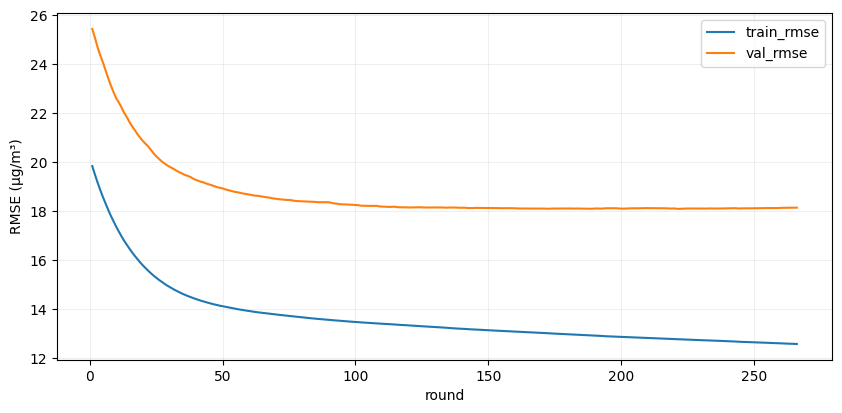

In [5]:
curve = pd.read_csv(RESULTS_DIR / "xgboost_canonical_learning_curve.csv")
axis = curve.plot(x="round", y=["train_rmse", "val_rmse"], figsize=(10, 4.5))
axis.set_ylabel("RMSE (µg/m³)")
axis.grid(alpha=0.2)
plt.show()

*Hình 1. Train RMSE và Validation RMSE của XGBoost theo boosting round; RMSE có đơn vị ug/m^3.*


Validation RMSE đạt cực tiểu 18,156 ug/m^3 tại vòng 199. Sau đó Train RMSE tiếp tục giảm, còn Validation RMSE tăng từ 18,156 lên 18,193 ug/m^3 tại vòng 244. Khoảng cách Train-Validation là 5,29 ug/m^3, tương đương 41,1% Train RMSE.

Đây là bằng chứng rõ về overfitting, dù mức tăng Validation sau cực tiểu không lớn. Early stopping khôi phục đúng vòng tối ưu theo Validation nhưng không thể xóa khoảng cách tổng quát hóa đã hình thành. Chỉ nên tăng regularization nếu Validation RMSE thực sự tốt hơn, không phải chỉ để hai đường nhìn gần nhau hơn.


## 4. Đánh giá trên tập Test

RMSE là metric chính vì nhấn mạnh các đỉnh bị dự đoán sai. MAE biểu diễn sai số tuyệt đối điển hình, còn R2 biểu diễn tỷ lệ biến thiên được giải thích. Kết quả được báo cáo cả tổng thể và theo thành phố để tránh che giấu failure mode địa lý. Test chỉ có vai trò mô tả và không được dùng ngược lại để thay đổi siêu tham số.

**Bảng 4. Hiệu năng XGBoost tổng hợp trên Train, Validation và Test; RMSE và MAE có đơn vị ug/m^3.**

**Bảng 5. Hiệu năng XGBoost trên Test theo thành phố; RMSE và MAE có đơn vị ug/m^3.**


### Nhận xét kết quả

Chỉ số theo thành phố phải được đọc cùng điểm tổng hợp. Hà Nội có độ biến thiên và số đỉnh ô nhiễm cao hơn rõ rệt, nên đóng góp phần lớn vào RMSE chung. Notebook lựa chọn cuối sẽ phân tích sâu hơn bằng các trường hợp lỗi và confusion matrix chẩn đoán trên các dải PM2.5.


In [6]:
display(pd.read_csv(RESULTS_DIR / "xgboost_canonical_metrics.csv"))
display(pd.read_csv(RESULTS_DIR / "xgboost_canonical_by_city.csv"))

,model,family,scope,horizon_hours,feature_set,train_rmse_ug_m3,train_mae_ug_m3,train_r2,train_bias_ug_m3,train_bucket_accuracy,...,test_rmse_ug_m3,test_mae_ug_m3,test_r2,test_bias_ug_m3,test_bucket_accuracy,test_bucket_f1_macro,test_usg_plus_recall,test_usg_plus_precision,test_unhealthy_plus_recall,test_unhealthy_plus_precision
0,XGBoost,gradient boosted trees,All three cities,24,weather_enriched,12.763552,8.587712,0.601155,-0.00192,0.739223,...,15.957416,10.231796,0.585605,0.279924,0.724845,0.307943,0.765761,0.685627,0.58408,0.686068


,model,city,rows,rmse_ug_m3,mae_ug_m3,r2,bias_ug_m3,bucket_accuracy,bucket_f1_macro,usg_plus_recall,usg_plus_precision,unhealthy_plus_recall,unhealthy_plus_precision
0,XGBoost,Hà Nội,4893,24.569272,18.103971,0.394778,-1.464239,0.510934,0.263933,0.902398,0.716098,0.656833,0.689198
1,XGBoost,TP.HCM,4893,10.396374,7.379792,0.313336,0.611055,0.809524,0.212977,0.367681,0.516447,0.000000,0.000000
2,XGBoost,Đà Nẵng,4893,7.223827,5.211625,0.489644,1.692955,0.854077,0.273840,0.503731,0.627907,0.250000,0.548387


## Hạn chế và tài liệu tham khảo

XGBoost xem mỗi dòng là một mẫu supervised thay vì mô hình hóa trạng thái thời gian ẩn. Vì vậy, cấu trúc thời gian phải được cung cấp qua lag và rolling features. Sự kiện cực đoan hiếm vẫn khó dự báo vì dữ liệu chủ yếu nằm ở dải trung bình và sản phẩm khí quyển dạng lưới có thể làm trơn đỉnh cục bộ.

**Tài liệu tham khảo**

Chen, T. và Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *Proceedings of KDD*. https://doi.org/10.1145/2939672.2939785
